<h1 style="text-align:center;">TREĆI PROJEKAT</h1>

<h2 style="font-style:italic; font-weight:bold; text-align: center;">
    Analiza sentimenta recenzija filmova sa platforme IMDB primenom neuronskih mreža
</h2>

## 1. Uvod
Cilj ovog projekta je primena veštačkih neuronskih mreža za analizu sentimenta tekstualnih podataka. Analiza sentimenta predstavlja važan zadatak u oblasti obrade prirodnog jezika (Natural Language Processing – NLP), čiji je cilj klasifikacija tekstualnih podataka na osnovu izraženog sentimenta.

U ovom slučaju posmatraju se tekstualne recenzije filmova, pri čemu svaka recenzija može imati pozitivan ili negativan sentiment. Automatska klasifikacija sentimenta omogućava analizu velikih količina tekstualnih podataka i može se primeniti u različitim oblastima kao što su analiza mišljenja 
korisnika, marketing i preporučivački sistemi.

Za potrebe ovog rada korišćene je IMDB dataset kojib sadrži 50000 filmskih recenzija. Svaka recenzija je označena kao pozitivna ili negativna.

Dataset je preuzet sa Kaggle platforme: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

Za implementaciju modela korišćene su sledeće biblioteke:
- Python
- Pandas
- Scikit-learn
- TensorFlow / Keras
- Matplotlib i Seaborn

U nastavku rada prikazana je analiza dataset-a, priprema podataka, implementacija neuronske mreže, treniranje modela i evaluacija dobijenih rezultata.

## 2. Opis skupa podataka
Dataset koji je korišćen u ovom projektu sadrži 50 000 filmskih recenzija preuzetih sa platforme IMDB.. Svaka recenzija je označena kao pozitivna ili negativna u zavisnosti od sentimenta koji izražava.

Dataset sadrži dve kolone:
- **review** - tesktualni sadržaj filmske recenzije
- **sentiment** - oznaka sentimenta (positive ili negative)

Podaci su uravnoteženi, što znači da postoji približno jedank broj pozitivnih i negativnih recenzija. To je važno jer omogućava modelu da uči bez pristrasnosti prema jednoj klasi.

Pre treniranja modela potrebno je izvršiti osnovnu analizu i pripremu podataka kako bi se tesktualni podaci mogli koristiti u modelu neuronske mreže.

## 3. Učitavanje biblioteka

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from wordcloud import STOPWORDS
from collections import Counter
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, Input
from tensorflow.keras.optimizers import Adam
plt.style.use('seaborn-v0_8')

## 4. Učitavanje skupa podataka
U ovom koraku učitavamo dataset u pandas DataFrame kako bismo mogli da analiziramo i obradimo podatke.

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Prikaz prvih nekoliko redova dataset-a omogućava uvid u strukturu podataka, nazive kolona i tipove vrednosti koje dataset sadrži. Na ovaj način možemo potvrditi da dataset sadrži tekstualne recenzije i odgovarajuće oznake sentimenta.

## 5. Deskriptivna analiza
Pre treniranja modela potrebno je analizirati osnovne karakteristike dataset-a kao što su broj instanci, distribucija klasa i eventualne nedostajuće vrednosti.

### Dimenzije dataset-a

In [3]:
df.shape

(50000, 2)

Dataset sadrži 50000 instanci i 2 kolone: tekst recenzije i oznaki sentimenta.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


Ova komanda pruža dodatne informacije o dataset-u, uključujući tipove podataka i broj nenedostajućih vrednosti u svakoj koloni.

### Provera nedostajućih vrednosti

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

Rezultati pokazuju da dataset ne sadrži nedostajuče vrednosti, što znači da nije potrebna dodatna obrada podataka u ovom koraku.

## 6. Primer recenzija iz dataset-a

U ovom delu prikazujemo nekoliko nasumičnih recenzija iz dataset-a kako bismo dobili bolji uvid u strukturu i sadržaj tekstualnih podataka koji će se koristiti za treniranje modela veštačke neuronske mreže.

In [6]:
print("Random positive review:")
print(df[df['sentiment']=='positive']['review'].sample(1).values[0])

print("\nRandom negative review:")
print(df[df['sentiment']=='negative']['review'].sample(1).values[0])

Random positive review:
"Yokai Daisenso" is a children's film by Takashi Miike, but as you might expect, it's probably a bit too dark & scary for younger ones. However, older children may well eat this up, that is, if you play it dubbed in English.<br /><br />The story is that of a young boy, who has moved with his mother to the country, to live with his grandfather, after a divorce. During a village festival the boy is chosen as a "Kirin rider", a great honor, but with that honor comes much danger and adventure, of course.<br /><br />Meanwhile, evil doings are at hand as a woman in a white mini skirt, go-go boots & a beehive hair-do, teams up with an evil Yokai to turn people's resentments and discarded items against them. And this evil has manifested itself as a flying city in the form of a monster that heads for the City of Rage itself, Tokyo. One quite funny scene has two derelicts watching the monster fly over the city...says one, "Oh, it's only Gamera". <br /><br />The young boy 

U prikazanim recenzijama mogu se primetiti HTML oznake poput $<br />$, koje su deo originalnog dataset-a i biće uklonjene u fazi pripreme podataka.

In [7]:
print("Random positive reviews:\n")
for review in df[df['sentiment']=='positive']['review'].sample(3):
    print(review)
    print("\n---\n")

print("Random negative reviews:\n")
for review in df[df['sentiment']=='negative']['review'].sample(3):
    print(review)
    print("\n---\n")

Random positive reviews:

Producer Joel Schumacher who also directed "Phone Booth",'02, and many other great films showed in great detail how no one person can really be trained to be a killing machine with out destroying their own personalities and the real fears that a person has to face when going into COMBAT!! Colin Farrell(Roland Bozz),"Intermission",'03, gave one of his best performances and actually carried this entire picture on his back. Matthew Davis(Jim Paxton),"Blue Crush",'02, gave a great supporting role and Shea Whigham(Pvt.Wilson),"All The Real Girls",'03, showed his true acting skills in the role that he played. There was two brief scenes where the soldiers were able to find some hot romance on a short leave in the local town and had to pay for their love and sexual desires. One Army Veteran instructor from Viet Nam told the soldiers how to really torture the enemy by using electrical wires in all the wrong places on a human male body. Enjoyable and entertaining film t

In [8]:
df['review'].str.len().describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review, dtype: float64

## 7.  Distribucija sentimenta 

In [9]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

### Vizuelizacija

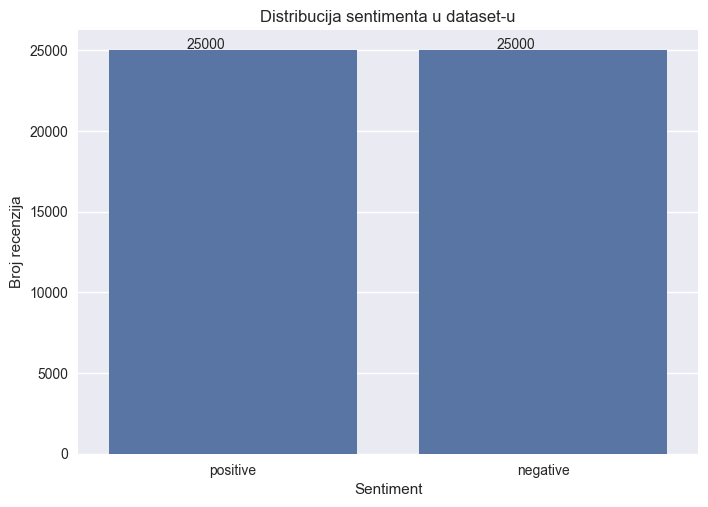

In [10]:
ax = sns.countplot(x='sentiment', data=df)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x()+0.25, p.get_height()+100))

plt.title("Distribucija sentimenta u dataset-u")
plt.xlabel("Sentiment")
plt.ylabel("Broj recenzija")
plt.show()

Iz grafika se može uočiti da dataset sadrži jednak broj pozitivnih i negativnih recenzija. To znači da je dataset balansiran, što je poželjno kod klasifikacionih problema jer model neće biti pristrasan prema jednoj klasi tokom treniranja.

In [11]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64

Pozitivne i negativne recenzije su ravnomerno raspoređene (50% / 50%).

## 8. WordCloud analiza recenzija
WordCloud predstavlja vizuelizaciju frekvencije reči u tekstualnim podacima. Veličina svake reči u grafiku proporcionalna je njenoj učestalosti u tekstu, odnosno reči koje se češće pojavljuju prikazane su većim fontom.

U nastavku su prikazani WordCloud grafici za pozitivne i negativne filmske recenzije.

### WordCloud za pozitivne recenzije

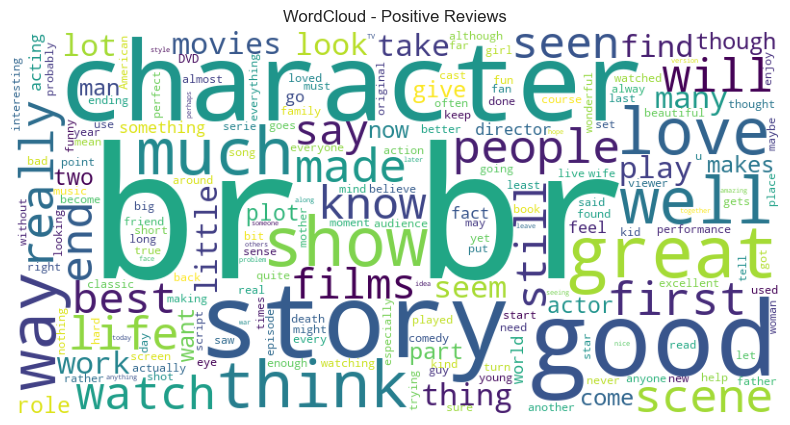

In [12]:
positive_reviews = df[df['sentiment'] == 'positive']['review']
text = " ".join(positive_reviews)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords = STOPWORDS.union({
    'movie','film','one','even','see','time','make','get'
})
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud - Positive Reviews")
plt.show()

### WorldCloud za negativne recenzije

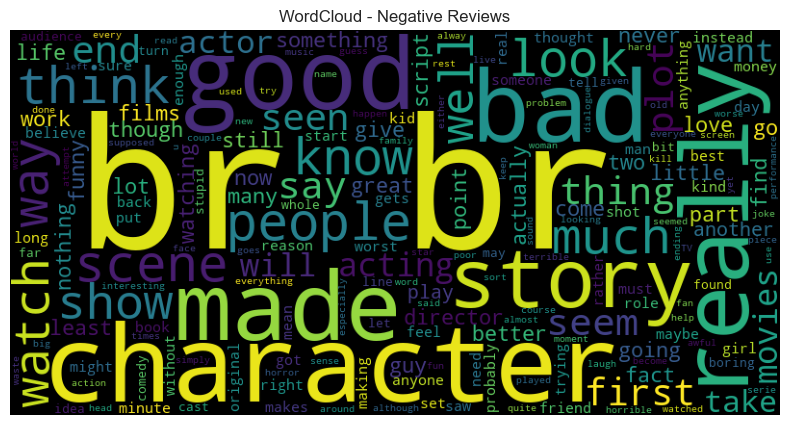

In [13]:
negative_reviews = df[df['sentiment'] == 'negative']['review']
text = " ".join(negative_reviews)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    stopwords = STOPWORDS.union({
    'movie','film','one','even','see','time','make','get'
})
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud - Negative Reviews")
plt.show()

Iz WordCloud vizuelizacije može se uočiti koje reči se najčešće pojavljuju u pozitivnim i negativnim recenzijama.

Kod pozitivnih recenzija dominiraju reči koje ukazuju na pozitivno iskustvo gledanja, kvalitet priče i likova. Kod negativnih recenzija češće se pojavljuju reči koje se odnose na kritiku filma, zaplet ili kvalitet produkcije.

Ovakva analiza pruža uvid u karakteristične termine koji se koriste u različitim tipovima recenzija i može biti korisna u procesu modelovanja sentimenta.

## 9. Analiza dužine recenzija
U ovom delu analiziramo dužinu tekstualnih recenzija u dataset-u. Dužina recenzije predstavlja broj reči koje se pojavljuju u jednoj recenziji. 
Ova analiza omogućava bolje razumevanje strukture tekstualnih podataka i raspodele dužine tekstova koji će biti korišćeni za treniranje modela.

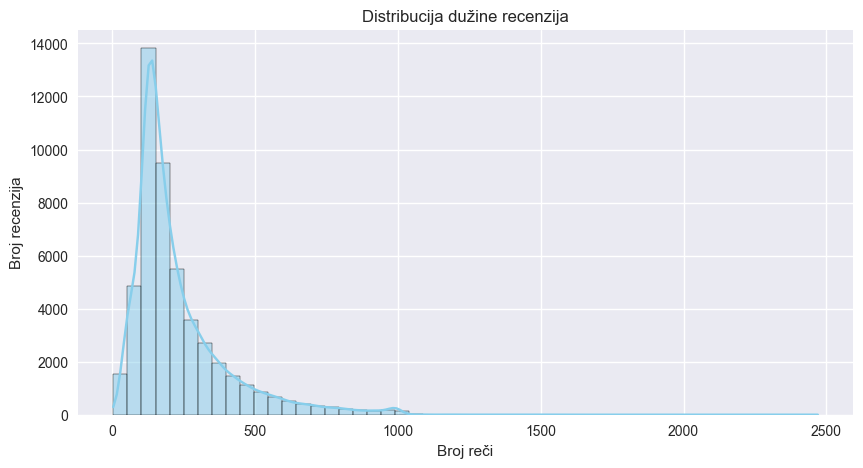

In [14]:
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')

plt.title("Distribucija dužine recenzija")
plt.xlabel("Broj reči")
plt.ylabel("Broj recenzija")

plt.show()

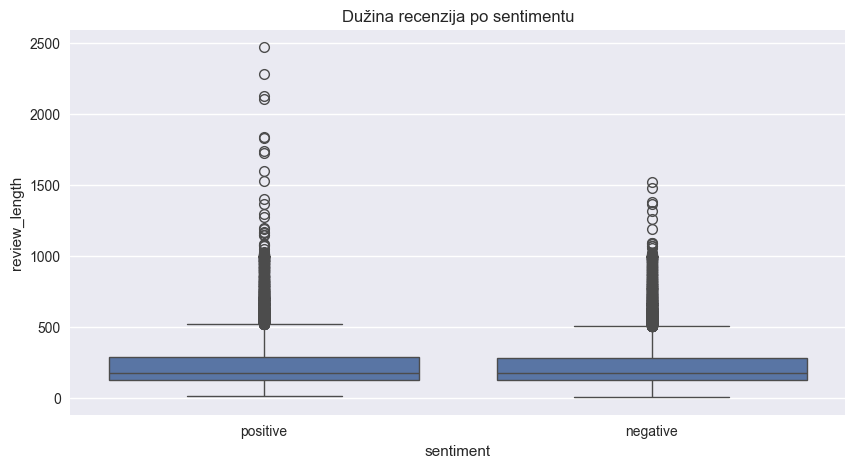

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x='sentiment', y='review_length', data=df)

plt.title("Dužina recenzija po sentimentu")

plt.show()

Histogram prikazuje raspodelu dužine recenzija u dataset-u. Može se primetiti da većina recenzija sadrži između približno 100 i 300 reči, dok manji broj recenzija ima znatno veću dužinu.

Boxplot grafikon prikazuje poređenje dužine recenzija u odnosu na sentiment. Može se uočiti da pozitivne i negativne recenzije imaju sličnu raspodelu dužine, što ukazuje da dužina teksta nije značajno povezana sa klasom sentimenta.

Prisustvo različitih dužina recenzija doprinosi raznovrsnosti tekstualnih podataka i može pomoći modelu da nauči različite obrasce u tekstu.

In [16]:
df['review_length'].describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64

Statistički pregled pokazuje prosečnu dužinu recenzije i raspon vrednosti u dataset-u.

## 10. Najčešće reči u recenzijama
U ovom delu analiziraju se najčešće reči koje se pojavljuju u filmskim recenzijama. Analiza frekvencije reči omogućava bolje razumevanje strukture tekstualnih podataka i identifikaciju reči koje se najčešće koriste u dataset-u.

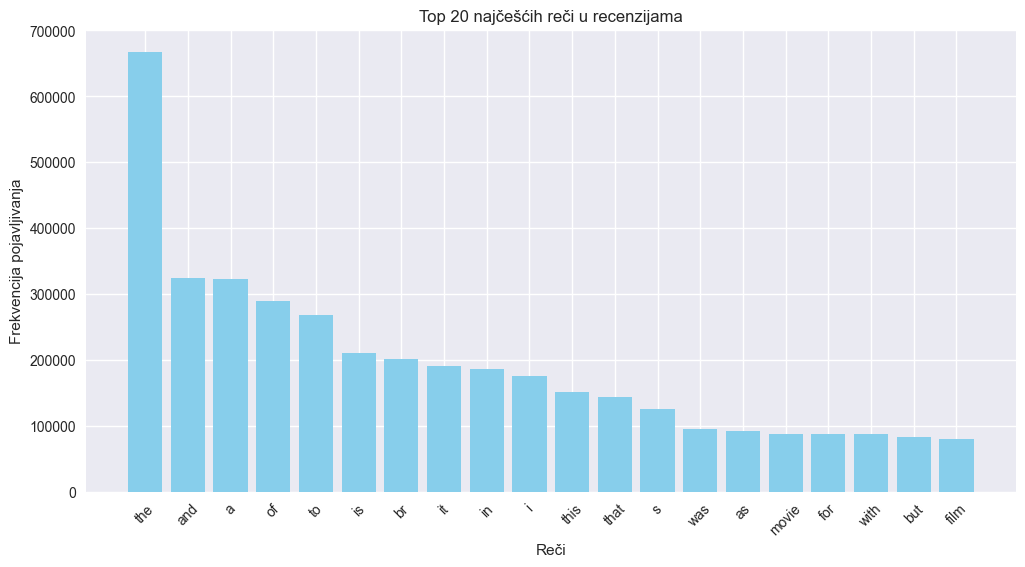

In [17]:
text = " ".join(df['review']).lower()
words = re.findall(r'\w+', text)
word_counts = Counter(words)
common_words = word_counts.most_common(20)
words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(12,6))
plt.bar(words, counts, color='skyblue')
plt.title("Top 20 najčešćih reči u recenzijama")
plt.xlabel("Reči")
plt.ylabel("Frekvencija pojavljivanja")
plt.xticks(rotation=45)
plt.show()

Iz grafa se moože primetiti da se među najčešćim rečima nalaze opšte reči enegleskog jezika kao što su "the", "and", "a", "of". Ove reči nemaju veliku semantičku vrednost za analizu sentimenta, zbog čega se u mnogim NLP motodama koriste tehnike uklanjanja stop reči pre treniranja modela.

## 11. Najčešće reči u pozitivnim i negativnim recenzijama

U ovom delu analiziraju se najčešće reči koje se pojavljuju u pozitivnim i negativnim filmskim recenzijama. Cilj ove analize je identifikacija karakterističnih termina koji se pojavljuju u različitim klasama sentimenta.

In [18]:
positive_reviews = " ".join(df[df['sentiment'] == 'positive']['review']).lower()
negative_reviews = " ".join(df[df['sentiment'] == 'negative']['review']).lower()
pos_words = re.findall(r'\w+', positive_reviews)
neg_words = re.findall(r'\w+', negative_reviews)
pos_counts = Counter(pos_words).most_common(15)
neg_counts = Counter(neg_words).most_common(15)

print("Top positive words:")
print(pos_counts)
print("\nTop negative words:")
print(neg_counts)

Top positive words:
[('the', 341281), ('and', 176634), ('a', 164323), ('of', 152105), ('to', 131322), ('is', 111830), ('in', 99250), ('br', 97954), ('it', 95133), ('i', 81997), ('this', 69648), ('that', 69593), ('s', 64675), ('as', 51106), ('with', 45718)]

Top negative words:
[('the', 326712), ('a', 158647), ('and', 147807), ('of', 137305), ('to', 136802), ('br', 103997), ('is', 99252), ('it', 95724), ('i', 93636), ('in', 87531), ('this', 81354), ('that', 74286), ('s', 60333), ('was', 52269), ('movie', 50117)]


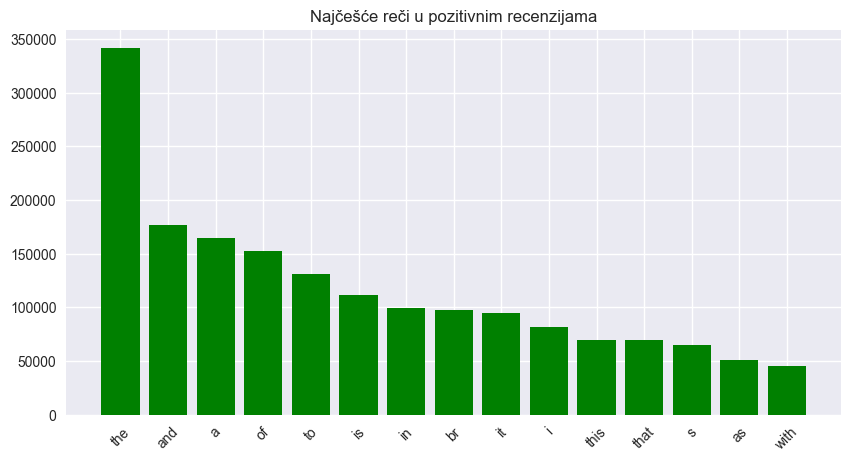

In [19]:
#pozitivne
pos_words = [word[0] for word in pos_counts]
pos_freq = [word[1] for word in pos_counts]

plt.figure(figsize=(10,5))
plt.bar(pos_words, pos_freq, color='green')
plt.title("Najčešće reči u pozitivnim recenzijama")
plt.xticks(rotation=45)
plt.show()

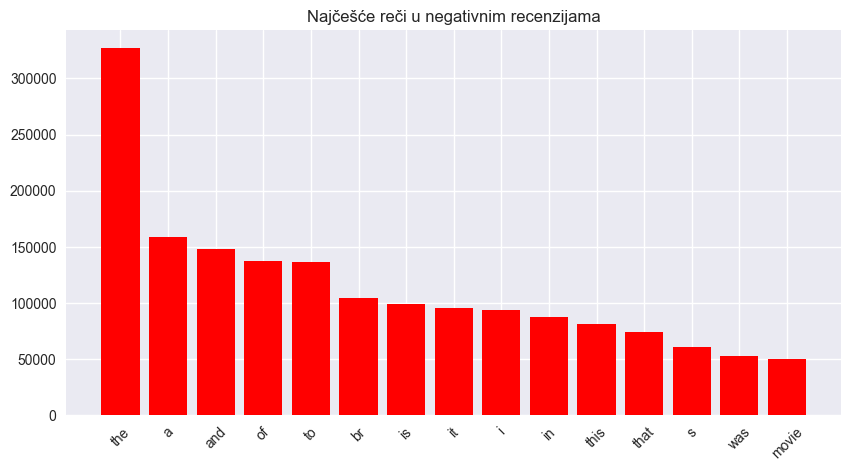

In [20]:
#negativne
neg_words = [word[0] for word in neg_counts]
neg_freq = [word[1] for word in neg_counts]

plt.figure(figsize=(10,5))
plt.bar(neg_words, neg_freq, color='red')
plt.title("Najčešće reči u negativnim recenzijama")
plt.xticks(rotation=45)
plt.show()

Iz prikazanih grafika može se primetiti da se u obe klase sentimenta najčešće pojavljuju opšte reči engleskog jezika kao što su "the", "and", "a", "of" i "to". Ove reči predstavljaju tzv. stop reči koje nemaju značajnu semantičku vrednost za analizu sentimenta. S obzirom na to da se iste reči pojavljuju i u pozitivnim i u negativnim recenzijama, može se zaključiti da frekvencija ovih reči ne doprinosi razlikovanju sentimenta. Zbog toga se u procesu pripreme podataka često primenjuju tehnike uklanjanja stop reči kako bi se model fokusirao na informativnije termine.

## 12. Priprema podataka
Tekstualni podaci moraju biti transformisani u numerički oblik kako bi ih model neuronske mreže mogao obraditi. U ovom koraku primenjuju se tehnike tokenizacije i pretvaranja teksta u sekvence brojeva koje predstavljaju reči u tekstu.

Koraci pripreme podataka:
- Pretvaranje sentimenata u numeričke vrednosti
- Tokenizaciju teksta
- Pretvaranje teksta u sekvence brojeva
- Padding sekvenci

### Kodiranje sentimenata

In [21]:
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])
df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,1,307
1,A wonderful little production. <br /><br />The...,1,162
2,I thought this was a wonderful way to spend ti...,1,166
3,Basically there's a family where a little boy ...,0,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,230


Sentiment oznake su pretvorene u numeričke vrednosti kako bi ih neuronska ,reža mogla koristiti u procesu treniranja. 
- Positive → 1
- Negative → 0

### Tokenizacija teksta
Tokenizacija predstavlja proces pretvranja teksta u niz tokena (reči) koji se zatim mapiraju na numeričke vrednosti.

In [22]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['review'])
X = tokenizer.texts_to_sequences(df['review'])

### Padding sekvenci

In [23]:
X = pad_sequences(X, maxlen = 200)

Padding se koristi kako bi se sekvence imale istu dužinu. U ovom slučaju maksimalna dužina sekvence je postavljena na 200, što omogućava modelu da efikasno obrađuje tekstulane podatke.

In [24]:
X.shape

(50000, 200)

In [25]:
#target promenljiva
y = df['sentiment']

### Podela na trening i test skup

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 200)
Test shape: (10000, 200)


Podaci su podeljeni na trening i test skup:
- Trening skup se koristi za treniranje neuronske mreže
- Test skup se koristi za eveluaciju performansi modela.

U ovom projektu korišćen je odnos 80% trenig podataka i 20% test podataka.

## 13. Kreiranje neuronske mreže
Za analizu sentimenata koristićemo LSTM (Long Short - Term Memory) neuronsku mrežu. 

LSTM mreže su posebno pogodne za obradu sekvencijalnih podataka kao što su tekstualni podaci jer mogu da pamte kontekst reči u rečenici.

In [28]:
model = Sequential()
model.add(Input(shape=(200,)))
model.add(Embedding(input_dim=10000, output_dim=128))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

Model neuronske mreže sastoji se od nekoliko slojeva:
- Embedding sloj pretvara reči u numeričke vektore
- LSTM sloj omgućava modelu da pamti kontekst reči u sekvenci
- Dropout sloj se korsiti za smanjenje overfitting-a tokom treniranja.
- DEnse sloj ssa sigmoid aktivacijom daje verovatnoću  da recenzija imapozitivan sentiment.

## 14. Kompajliranje modela
Pre treniranja modela potrebno je definisati:
- optimizator
- loss funkciju
- metriku evaluacije

Za ovaj problem koristi se **binary_crossentropy** jer se radi o binarnoj klasifikaciji.

In [29]:
model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

Iz prikaza arhitekture modela može se videti broj slojeva, dimenzije izlaza svakog sloja i broj parametara koji se treniraju.

Ukupan broj parametara modela iznosi 1,329,473 što predstavlja parametre koje neuronska mreža uči tokom procesa treniranja.

## 15. Treniranje modela

Model se trenira korišćenjem trening skupa podataka. Tokom treniranja model prolazi kroz više epoha (epochs) kako bi postepeno učio obrasce u tekstualnim podacima.

Parametar bath_size određuje koliko uzoraka model obrađuje u jednom koraku treniranja.

In [30]:
history = model.fit(
    X_train,
    y_train,
    epochs = 5,
    batch_size = 64,
    validation_split = 0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 125ms/step - accuracy: 0.8270 - loss: 0.3869 - val_accuracy: 0.8742 - val_loss: 0.3090
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 111ms/step - accuracy: 0.9050 - loss: 0.2451 - val_accuracy: 0.8836 - val_loss: 0.2836
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 112ms/step - accuracy: 0.9316 - loss: 0.1850 - val_accuracy: 0.8781 - val_loss: 0.3087
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.9486 - loss: 0.1417 - val_accuracy: 0.8555 - val_loss: 0.3854
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 109ms/step - accuracy: 0.9608 - loss: 0.1112 - val_accuracy: 0.8775 - val_loss: 0.3980


Tokom procesa treniranja može se primetiti da tačnost modela postepeno raste sa svakom epohom, dok vrednost funkcije gubitka (loss) opada. To ukazuje da model uspešno uči obrasce u tekstualnim podacima. Validaciona tačnost se stabilizuje oko 88%, što pokazuje da model dobro generalizuje na podacima koji nisu korišćeni tokom treniranja. Blaga razlika između trening i validacione tačnosti može ukazivati na početak overfittinga, što je uobičajeno kod modela sa velikim brojem parametara.

## 16. Vuzuelizacija rezultata
### Accuracy graf

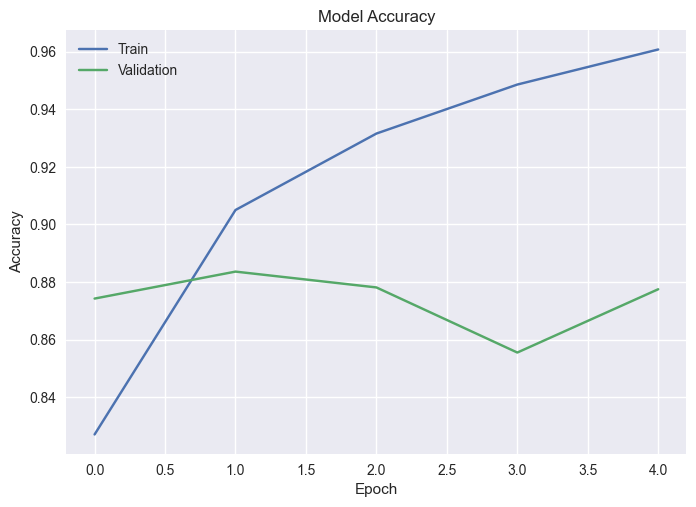

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

Iz grafa tačnosti može se videti tačnost modela postepeno povećava tokom treniranja.

Razlika između trening i validacionog skupa pokazuje koliko model uspešno generalizuje na novim podacima.

### Loss graf

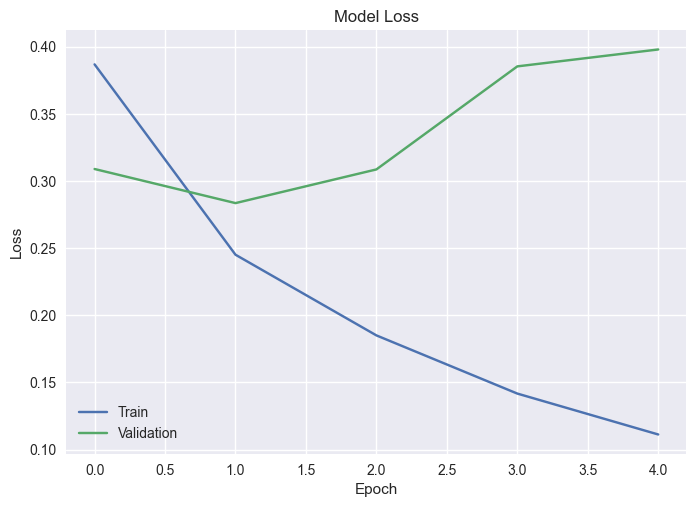

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

Graf funkcije gubitka prikazuje promenu vrednosti loss funkcije tokom treninga modela. Vrednost loss funkcije na trening skupu opada kako model uči obrasce u podacima. 

Vrednost loss funkcije na validacionom skupu pokazuje kako model generalizuje na podacima koji nisu korišćeni tokom treniranja. Blagi rast validacionog loss-a može ukazivati na početak overfittinga.

Smanjenje vrednosti loss funkcije na trening skupu ukazuje na to da model uspešno uči obrasce u podacima, dok vrednosti na validacionom skupu pokazuje sposobnost modela da generalizuje na neviđene podatke.

## 17. Evaluacija modela 

In [33]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8785 - loss: 0.3818
Test accuracy: 0.8784999847412109


Rezultati evaluacije pokazuju da model postiže tačnost od približno 88% na test skupu podataka. Ovaj rezultat ukazuje da model uspešno klasifikuje većinu pozitivnih i negativnih filmskih recenzija koje nisu korišćene tokom treniranja.

Dobijeni rezultati pokazuju da LSTM neuronska mreža može efikasno da uči obrasce u tekstualnim podacima i primeni ih na nove primere.

## 18. Confusion matrix
Confusion matrix predstavja tabelu koja prikazuje performanse klasifikacionog modela poređenjem stvarnih i predviđenih vrednosti.

Matrica omogućava bolju analizu tačnosti modela i prikazuje:
- True positive (TP)
- True negative (TN)
- False positive (FP)
- False negative (FN)

In [34]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step


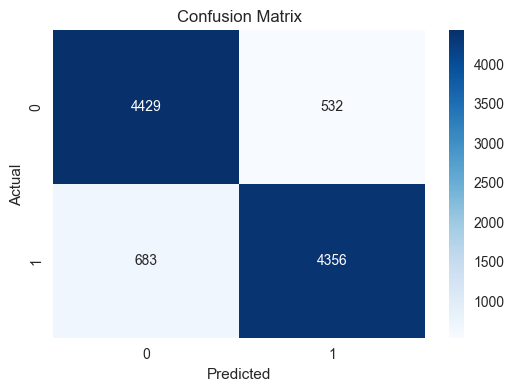

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Iz confusion matrix može se videti raspodela tačno i pogrešno klasifikovanih recenzija. Model je uspešno klasifikovao veliki broj pozitivnih i negativnih recenzija, dok manji broj recenzija nije pravilno klasifikovan.

Ova analiza omogućava bolji uvid u performase modela u odnosu na pojedinačne klase.

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4961
           1       0.89      0.86      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



Classification report prikazuje detaljne metrike performansi modela:
- Precision - odnos tačno predviđenih pozitivnih instanci i svih predviđenih pozitivnih instanci
- Recall - odnos tačno predviđenih pozitivnih instanci i svih stvarnih pozitivnih instanci
- F1-score - harmonijska sredina precision i recall metrike

Confusion matrix prikazuje raspodelu tačno i netačno klasifikovanih primera. Model je uspešno klasifikovao veliki broj pozitivnih i negativnih recenzija, dok je relativno mali broj recenzija pogrešno klasifikovan. Classification report dodatno potvrđuje performanse modela. Precision, recall i F1-score vrednosti za obe klase iznose približno 0.88, što ukazuje na uravnotežene performanse modela. Ovi rezultati pokazuju da LSTM neuronska mreža može efikasno da prepozna obrasce u tekstualnim recenzijama i da uspešno razlikuje pozitivne i negativne sentimente.

## 19. ROC AUC analiza
ROC kriva prikazuje odnos između True Positive Rate i False Positive Rate za različite pragove klasifikacije. AUC vrednost predstavlja meru kvaliteta modela.

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step


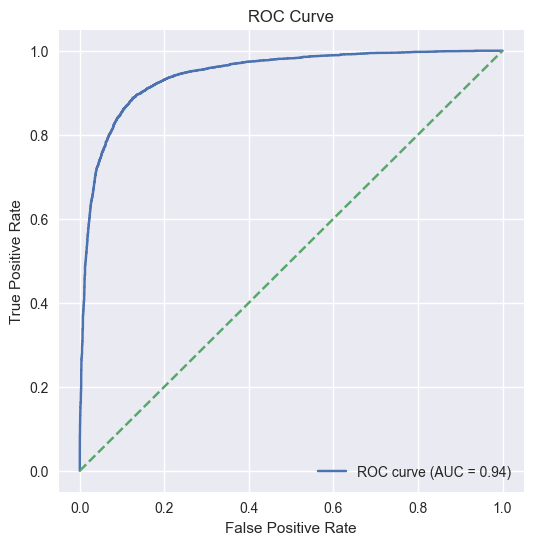

In [37]:
y_pred_prob = model.predict(X_test)
fpr, tpr, threshold = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ROC kriva prikazuje odnos između True Positive Rate i False Positive Rate za različite pragove klasifikacije. Vrednost AUC iznosi približno 0.95, što ukazuje na veoma dobre performanse modela u razlikovanju pozitivnih i negativnih recenzija.

Što je vrednost AUC bliža 1, model ima bolju sposobnost klasifikacije.

## 20. Sumirani rezultati modela

In [38]:
acuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8784999847412109
Precision: 0.8911620294599017
Recall: 0.8644572335780909
F1-score: 0.8776065276518585


## 21. Predikcija sentimenata nove recenzije
Model se može koristiti i za predikciju sentimenata novih filmskih recenzija koje nisu deo trening skupa.

In [39]:
sample_review = ["This movie was amazing and I really enjoyed it"]
sequence = tokenizer.texts_to_sequences(sample_review)
padded = pad_sequences(sequence, maxlen=200)
prediction = model.predict(padded)
if prediction > 0.5:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Sentiment: Positive


U ovom primeru model je korišćen za predikciju sentimenata nove filmske recenzije koja nije deo trening skupa. Tekst recenzije se prvo pretvara u numeričku sekvencu koristeći toknizer, zatim se sekvenca prilagođava na odgovarajuču dužinu korišćenjem padding tehnike.

Na osnovu dobijene verovatnoće model određuje da li recenzija ima pozitavna ili negativan sentiment.

In [40]:
sample_review = ["This movie was terrible and boring"]
sequence = tokenizer.texts_to_sequences(sample_review)
padded = pad_sequences(sequence, maxlen=200)
prediction = model.predict(padded)
if prediction > 0.5:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Sentiment: Negative


## 22. Analiza rezultata
Rezultati pokazuju da neuronska mreža uspešno klasifikuje sentiment filmskih recenzija. Model postiže visoku tačnost na test skupu podataka, što ukazuje na sposobnost LSTM mreže da prepozna obrasce u tekstualnim podacima.

Analiza ROC krive i AUC vrednosti dodatno potvrđuje kvalitet modela, dok metrike poput precision, recall i F1-score pokazuju uravnotežene performanse u klasifikaciji pozitivnih i negativnih recenzija.

Vizuelizacija accuracy i loss funkcija pokazuje stabilan proces treniranja modela uz blagu razliku između trening i validacionih rezultata.

## 23. Zaključak
U ovom projektu implementirana je veštačka neuronska mreža za analizu sentimenta filmskih recenzija sa platforme IMDB. Korišćenjem LSTM neuronske mreže omogućena je obrada tekstualnih podataka i klasifikacija recenzija na pozitivne i negativne.

Tokom projekta izvršena je analiza skupa podataka, priprema tekstualnih podataka kroz tokenizaciju i padding sekvenci, kao i implementacija i treniranje modela neuronske mreže korišćenjem biblioteke TensorFlow/Keras. Takođe su prikazane različite metode evaluacije modela, uključujući accuracy, precision, recall, F1-score, confusion matrix i ROC AUC analizu.

Rezultati pokazuju da model postiže tačnost od približno 88% na test skupu podataka, dok ROC AUC vrednost od oko 0.95 ukazuje na veoma dobre performanse modela u razlikovanju pozitivnih i negativnih recenzija. Ovi rezultati potvrđuju da LSTM neuronske mreže mogu efikasno da uče obrasce u tekstualnim podacima i uspešno primene naučeno na novim primerima.

Dobijeni rezultati pokazuju da veštačke neuronske mreže predstavljaju veoma efikasan pristup za analizu sentimenta i obradu prirodnog jezika. U budućem radu moguće je unaprediti model korišćenjem naprednijih tehnika obrade teksta, većih neuronskih mreža ili unapred treniranih modela za obradu prirodnog jezika.
